# Data Loading

In [ ]:
import zipfile
import os
import pandas as pd
import numpy as np
import pickle

# ========= 1. unzip =========
zip_path = "/content/battery.zip"
extract_path = "/content/battery_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzip done.")

# ========= 2. locate metadata =========
base_dir = "/content/battery_data/cleaned_dataset"
data_dir = os.path.join(base_dir, "data")


candidate_meta_files = [
    os.path.join(base_dir, "metadata.csv")
]

meta_path = None
for p in candidate_meta_files:
    if os.path.exists(p):
        meta_path = p
        break

if meta_path is None:
    raise FileNotFoundError("Metadata file not found in cleaned_dataset/")

meta_df = pd.read_csv(meta_path)
print("Metadata loaded from:", meta_path)
print("Metadata rows:", len(meta_df))

# ========= 3. keep only discharge =========
meta_df = meta_df[meta_df["type"] == "discharge"].copy()

# 如果 capacity 之后要当 label，建议先去掉缺失
if "Capacity" in meta_df.columns:
    meta_df = meta_df.dropna(subset=["Capacity"])

print("Discharge rows in metadata:", len(meta_df))

# filename -> metadata row
meta_map = {row["filename"]: row for _, row in meta_df.iterrows()}

# ========= 4. read trajectory csv correctly =========
dataset = []

required_cols = [
    "Voltage_measured",
    "Current_measured",
    "Temperature_measured",
    "Current_load",
    "Voltage_load",
    "Time",
]

for file in os.listdir(data_dir):
    if not file.endswith(".csv"):
        continue
    if file not in meta_map:
        continue

    file_path = os.path.join(data_dir, file)

    try:
        df = pd.read_csv(file_path)
    except Exception as e:
        print(f"Skip {file}: read error -> {e}")
        continue

    # 检查列是否齐全
    if not all(col in df.columns for col in required_cols):
        print(f"Skip {file}: missing columns -> {set(required_cols) - set(df.columns)}")
        continue

    # 只保留需要的列，并去掉缺失
    df = df[required_cols].dropna().copy()

    # 太短的轨迹先过滤
    if len(df) < 20:
        continue

    meta = meta_map[file]

    dataset.append({
        "file": file,
        "battery_id": meta.get("battery_id", None),
        "test_id": meta.get("test_id", None),
        "ambient_temperature": meta.get("ambient_temperature", np.nan),
        "capacity": meta.get("Capacity", np.nan),
        "trajectory_df": df,  # 保留完整 dataframe，最稳
        "trajectory_array": df[[
            "Voltage_measured",
            "Current_measured",
            "Temperature_measured",
            "Current_load",
            "Voltage_load",
            "Time",
        ]].to_numpy(dtype=np.float32),
    })

print("Usable discharge trajectories:", len(dataset))

Unzip done.
Metadata loaded from: /content/battery_data/cleaned_dataset/metadata.csv
Metadata rows: 7565
Discharge rows in metadata: 2794
Usable discharge trajectories: 2768


# EDA

In [ ]:
lengths = [len(d["trajectory_df"]) for d in dataset]

import numpy as np

print("Num trajectories:", len(lengths))
print("Avg length:", np.mean(lengths))
print("Min length:", np.min(lengths))
print("Max length:", np.max(lengths))
print("Median length:", np.median(lengths))

Num trajectories: 2768
Avg length: 278.1199421965318
Min length: 24
Max length: 653
Median length: 265.5


In [ ]:
def get_cutoff_index(df_traj):
    v = df_traj["Voltage_measured"].to_numpy(dtype=float)
    return int(np.argmin(v))

In [ ]:
cutoff_temps = []
cutoff_voltages = []
cutoff_times = []
capacities = []
ambient_temps = []

for d in dataset:
    df = d["trajectory_df"]

    idx = get_cutoff_index(df)
    if idx is None:
        continue

    try:
        cutoff_temp = float(df["Temperature_measured"].iloc[idx])
        cutoff_voltage = float(df["Voltage_measured"].iloc[idx])
        cutoff_time = float(df["Time"].iloc[idx])
        capacity = float(d["capacity"])
        ambient_temp = float(d["ambient_temperature"])
    except (ValueError, TypeError):
        continue

    cutoff_temps.append(cutoff_temp)
    cutoff_voltages.append(cutoff_voltage)
    cutoff_times.append(cutoff_time)
    capacities.append(capacity)
    ambient_temps.append(ambient_temp)

In [ ]:
import numpy as np

cutoff_temps = np.array(cutoff_temps, dtype=float)
capacities = np.array(capacities, dtype=float)
ambient_temps = np.array(ambient_temps, dtype=float)
cutoff_times = np.array(cutoff_times, dtype=float)

print("corr(cutoff_temp, capacity):", np.corrcoef(cutoff_temps, capacities)[0, 1])
print("corr(cutoff_temp, ambient_temp):", np.corrcoef(cutoff_temps, ambient_temps)[0, 1])
print("corr(cutoff_time, capacity):", np.corrcoef(cutoff_times, capacities)[0, 1])

corr(cutoff_temp, capacity): 0.5332995598058626
corr(cutoff_temp, ambient_temp): 0.8815048842666549
corr(cutoff_time, capacity): 0.47947830109661793


In [ ]:
import numpy as np
import pandas as pd

# 转成 numeric + 去 NaN
ct = pd.to_numeric(pd.Series(cutoff_times), errors="coerce")
cp = pd.to_numeric(pd.Series(capacities), errors="coerce")

mask = ct.notna() & cp.notna()

ct = ct[mask].to_numpy(dtype=float)
cp = cp[mask].to_numpy(dtype=float)

print("valid samples:", len(ct))

corr = np.corrcoef(ct, cp)[0, 1]
print("corr(cutoff_time, capacity):", corr)

valid samples: 2743
corr(cutoff_time, capacity): 0.47947830109661793


## Distribution: Capacity

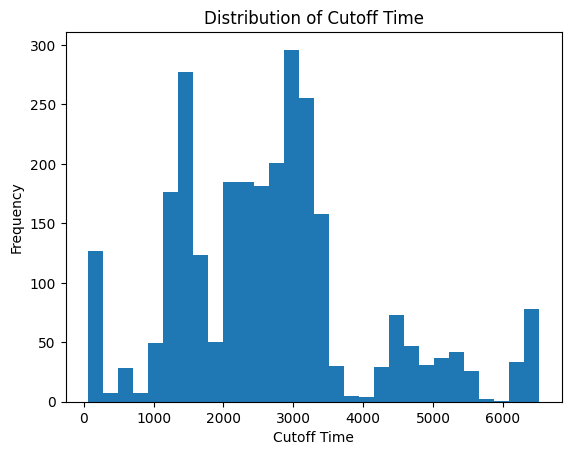

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(ct, bins=30)
plt.xlabel("Cutoff Time")
plt.ylabel("Frequency")
plt.title("Distribution of Cutoff Time")
plt.show()

## Distribution: Capacity

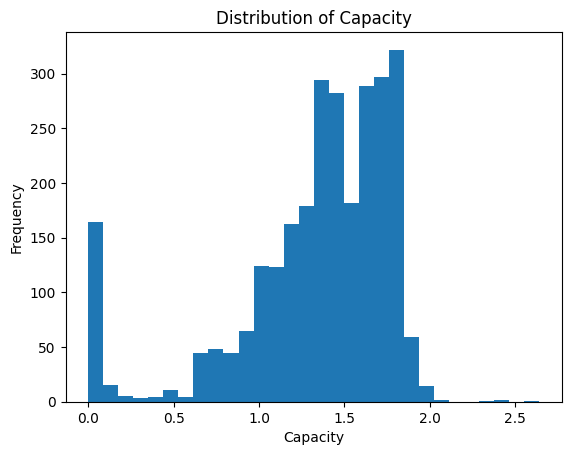

In [ ]:
plt.figure()
plt.hist(cp, bins=30)
plt.xlabel("Capacity")
plt.ylabel("Frequency")
plt.title("Distribution of Capacity")
plt.show()

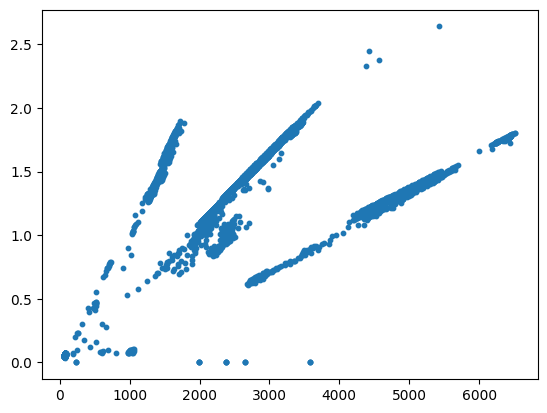

In [ ]:
plt.scatter(ct, cp, s=10)

Residual threshold: -0.3501391277871985
Num unstable points: 549


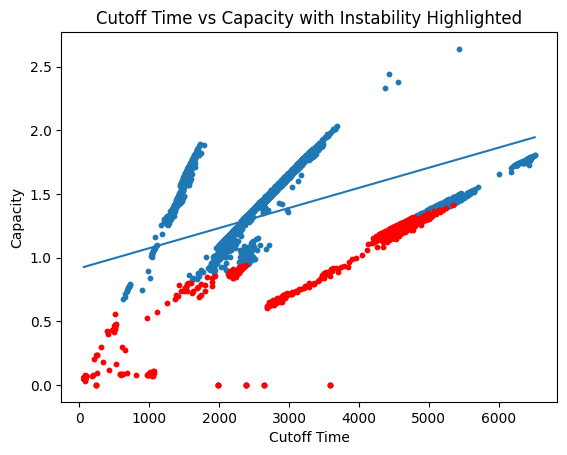

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ===== 1. 拟合全局线 =====
coef = np.polyfit(ct, cp, 1)
poly_fn = np.poly1d(coef)

# 预测值
pred = poly_fn(ct)

# ===== 2. 计算 residual =====
residual = cp - pred

# ===== 3. 定义 instability（最差20%）=====
threshold = np.percentile(residual, 20)
labels = residual < threshold  # True = instability

print("Residual threshold:", threshold)
print("Num unstable points:", np.sum(labels))

# ===== 4. 画图 =====
plt.figure()

# 正常点
plt.scatter(ct[~labels], cp[~labels], s=10)

# 不稳定点（标红）
plt.scatter(ct[labels], cp[labels], s=10, color='red')

# 拟合线
x_sorted = np.sort(ct)
plt.plot(x_sorted, poly_fn(x_sorted))

plt.xlabel("Cutoff Time")
plt.ylabel("Capacity")
plt.title("Cutoff Time vs Capacity with Instability Highlighted")

plt.show()

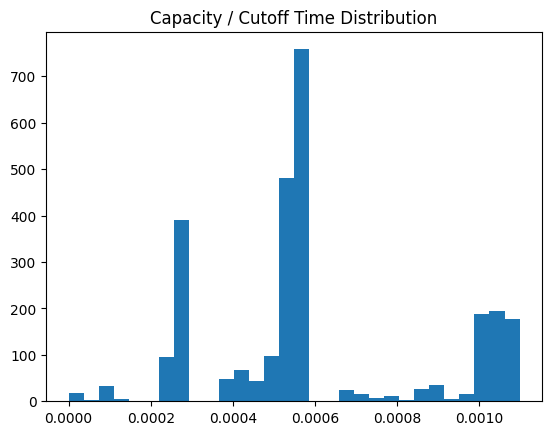

In [ ]:
ratio = cp / ct

plt.figure()
plt.hist(ratio, bins=30)
plt.title("Capacity / Cutoff Time Distribution")
plt.show()

In [ ]:
import pandas as pd
import numpy as np

df_all = pd.DataFrame({
    "cutoff_time": ct,
    "capacity": cp,
    "ratio": cp / ct,
    "battery_id": [d["battery_id"] for d in dataset[:len(ct)]],
    "ambient_temp": [d["ambient_temperature"] for d in dataset[:len(ct)]],
})

In [ ]:
def assign_cluster(r):
    if r < 0.0004:
        return "low"
    elif r < 0.0007:
        return "mid"
    else:
        return "high"

df_all["cluster"] = df_all["ratio"].apply(assign_cluster)

In [ ]:
print(df_all.groupby("cluster")["battery_id"].value_counts())

cluster  battery_id
high     B0033         57
         B0034         52
         B0036         47
         B0007         43
         B0006         42
                       ..
mid      B0025         14
         B0028         13
         B0049         13
         B0052         13
         B0051         11
Name: count, Length: 102, dtype: int64


In [ ]:
pivot = pd.crosstab(df_all["cluster"], df_all["battery_id"])
print(pivot)

battery_id  B0005  B0006  B0007  B0018  B0025  B0026  B0027  B0028  B0029  \
cluster                                                                     
high           40     42     43     33      3      6      4      7      6   
low            30     32     35     28     11      5      6      8      9   
mid            96     90     90     68     14     17     18     13     25   

battery_id  B0030  ...  B0047  B0048  B0049  B0050  B0051  B0052  B0053  \
cluster            ...                                                    
high           10  ...     21     18      7      6      7      5     17   
low             8  ...     20     18      5      4      7      6     10   
mid            22  ...     31     36     13     15     11     13     26   

battery_id  B0054  B0055  B0056  
cluster                          
high           21     24     22  
low            19     16     25  
mid            62     60     54  

[3 rows x 34 columns]


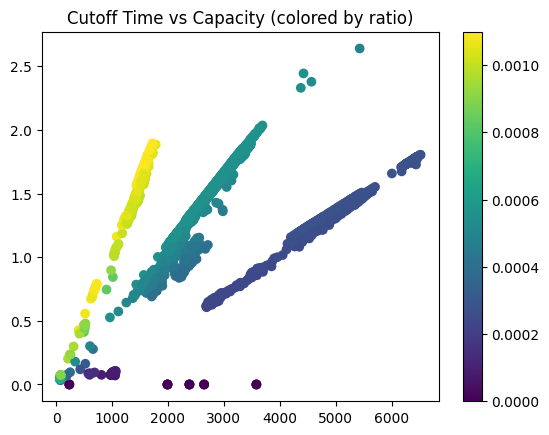

In [ ]:
plt.figure()
plt.scatter(ct, cp, c=cp/ct)
plt.colorbar()
plt.title("Cutoff Time vs Capacity (colored by ratio)")
plt.show()

# Data Preprocessing

### Dataframe Creation

In [ ]:
import pandas as pd
import numpy as np

def safe_float(x):
    try:
        return float(x)
    except:
        return None

rows = []

for d in dataset:
    df_traj = d["trajectory_df"].copy()

    # 保证数值列是 numeric
    for col in ["Voltage_measured", "Current_measured", "Temperature_measured",
                "Current_load", "Voltage_load", "Time"]:
        df_traj[col] = pd.to_numeric(df_traj[col], errors="coerce")

    df_traj = df_traj.dropna(subset=["Voltage_measured", "Time"])
    if len(df_traj) == 0:
        continue

    cutoff_idx = get_cutoff_index(df_traj)
    cutoff_time = float(df_traj["Time"].iloc[cutoff_idx])

    capacity = safe_float(d["capacity"])
    if capacity is None:
        continue

    ambient_temp = safe_float(d["ambient_temperature"])
    if ambient_temp is None:
        ambient_temp = np.nan

    ratio = capacity / cutoff_time
    label = int(ratio < 0.0004)

    rows.append({
        "battery_id": d["battery_id"],
        "ambient_temp": ambient_temp,
        "cutoff_time": cutoff_time,
        "capacity": capacity,
        "ratio": ratio,
        "label": label,
        "traj_len": len(df_traj),
        "trajectory_df": df_traj,
    })

df = pd.DataFrame(rows)

print("Total samples:", len(df))
print(df["label"].value_counts())

Total samples: 2743
label
0    2153
1     590
Name: count, dtype: int64


In [ ]:
print("\nLabel counts:")
print(df["label"].value_counts())

print("\nLabel proportion:")
print(df["label"].value_counts(normalize=True))


Label counts:
label
0    2153
1     590
Name: count, dtype: int64

Label proportion:
label
0    0.784907
1    0.215093
Name: proportion, dtype: float64


In [ ]:
print("\nLabel by battery:")
print(pd.crosstab(df["battery_id"], df["label"]))


Label by battery:
label         0   1
battery_id         
B0005       168   0
B0006       168   0
B0007       168   0
B0018       132   0
B0025        28   0
B0026        28   0
B0027        28   0
B0028         0  28
B0029        40   0
B0030        40   0
B0031        40   0
B0032        40   0
B0033       196   1
B0034       197   0
B0036       197   0
B0038        20  27
B0039        18  29
B0040        20  27
B0041        36  25
B0042        40  66
B0043        80  26
B0044        80  26
B0045         0  72
B0046         0  72
B0047         0  72
B0048         0  72
B0049        24   1
B0050        18   3
B0051        24   1
B0052         4   0
B0053        55   0
B0054        60  42
B0055       102   0
B0056       102   0


### Train/Test Split

In [ ]:
df_stable = df[df["label"] == 0].sample(frac=1, random_state=42).copy()
df_unstable = df[df["label"] == 1].copy()

train_df = df_stable.iloc[:1500].copy()
stable_test_df = df_stable.iloc[1500:].copy()
unstable_test_df = df_unstable.copy()

In [ ]:
feature_cols = [
    "Voltage_measured",
    "Current_measured",
    "Temperature_measured",
    "Current_load",
    "Voltage_load"
]

def extract_full_traj(df_traj):
    return df_traj[feature_cols].dropna().values.astype(np.float32)

In [ ]:
X_train_raw = [extract_full_traj(d["trajectory_df"]) for _, d in train_df.iterrows()]

### Normalization

In [ ]:
import numpy as np

# 拼接所有时间点（关键）
all_train_points = np.concatenate(X_train_raw, axis=0)

mean = all_train_points.mean(axis=0, keepdims=True)
std = all_train_points.std(axis=0, keepdims=True) + 1e-8

print("Mean:", mean)
print("Std:", std)

Mean: [[ 3.435992  -1.8283821 30.837454   1.7018709  1.7876395]]
Std: [[ 0.31834808  1.2389674  11.485278    1.3979255   1.0823101 ]]


In [ ]:
def normalize_traj(x):
    return (x - mean) / std

In [ ]:
# ===== train stable =====
X_train_stable = [
    normalize_traj(extract_full_traj(d["trajectory_df"]))
    for _, d in train_df.iterrows()
]

# ===== eval stable =====
X_eval_stable = [
    normalize_traj(extract_full_traj(d["trajectory_df"]))
    for _, d in stable_test_df.iterrows()
]

# ===== eval unstable =====
X_eval_unstable = [
    normalize_traj(extract_full_traj(d["trajectory_df"]))
    for _, d in unstable_test_df.iterrows()
]

In [ ]:
print("Train size:", len(X_train_stable))
print("Stable eval size:", len(X_eval_stable))
print("Unstable eval size:", len(X_eval_unstable))

print("Example shape:", X_train_stable[0].shape)

Train size: 1500
Stable eval size: 653
Unstable eval size: 590
Example shape: (233, 5)


### Prefix Split

In [ ]:
import numpy as np

def build_sliding_pairs(X_seq_list, k=10):
    """
    X_seq_list: list of arrays, each shape (T_i, D)

    Output:
        x      : (M, k*D)
        o_hist : (M, k, D)
        o_next : (M, k, D)
    """
    x_list = []
    hist_list = []
    next_list = []

    for seq in X_seq_list:
        seq = np.asarray(seq, dtype=np.float32)
        T, D = seq.shape

        if T < 3 * k:
            continue

        context = seq[:k].reshape(-1)   # (k*D,)

        suffix = seq[k:]                # 后面再滑窗
        L = suffix.shape[0]

        for start in range(L - 2 * k + 1):
            o_hist = suffix[start:start + k, :]
            o_next = suffix[start + k:start + 2 * k, :]

            x_list.append(context)
            hist_list.append(o_hist)
            next_list.append(o_next)

    x = np.asarray(x_list, dtype=np.float32)         # (M, 50)
    o_hist = np.asarray(hist_list, dtype=np.float32) # (M, 10, 5)
    o_next = np.asarray(next_list, dtype=np.float32) # (M, 10, 5)

    return x, o_hist, o_next

In [ ]:
k = 10

x_train, o_hist_train, o_next_train = build_sliding_pairs(X_train_stable, k=k)
x_eval_stable, o_hist_eval_stable, o_next_eval_stable = build_sliding_pairs(X_eval_stable, k=k)
x_eval_unstable, o_hist_eval_unstable, o_next_eval_unstable = build_sliding_pairs(X_eval_unstable, k=k)

print("Train:")
print("x_train shape:", x_train.shape)
print("o_hist_train shape:", o_hist_train.shape)
print("o_next_train shape:", o_next_train.shape)

print("\nEval stable:")
print("x_eval_stable shape:", x_eval_stable.shape)
print("o_hist_eval_stable shape:", o_hist_eval_stable.shape)
print("o_next_eval_stable shape:", o_next_eval_stable.shape)

print("\nEval unstable:")
print("x_eval_unstable shape:", x_eval_unstable.shape)
print("o_hist_eval_unstable shape:", o_hist_eval_unstable.shape)
print("o_next_eval_unstable shape:", o_next_eval_unstable.shape)

Train:
x_train shape: (336148, 50)
o_hist_train shape: (336148, 10, 5)
o_next_train shape: (336148, 10, 5)

Eval stable:
x_eval_stable shape: (145807, 50)
o_hist_eval_stable shape: (145807, 10, 5)
o_next_eval_stable shape: (145807, 10, 5)

Eval unstable:
x_eval_unstable shape: (202953, 50)
o_hist_eval_unstable shape: (202953, 10, 5)
o_next_eval_unstable shape: (202953, 10, 5)


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class TSAPairDataset(Dataset):
    def __init__(self, x, o_hist, o_next):
        assert len(x) == len(o_hist) == len(o_next)
        self.x = torch.tensor(x, dtype=torch.float32)
        self.o_hist = torch.tensor(o_hist, dtype=torch.float32)
        self.o_next = torch.tensor(o_next, dtype=torch.float32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.o_hist[idx], self.o_next[idx]


# -----------------------------
# Build datasets
# -----------------------------
train_dataset = TSAPairDataset(x_train, o_hist_train, o_next_train)
eval_stable_dataset = TSAPairDataset(x_eval_stable, o_hist_eval_stable, o_next_eval_stable)
eval_unstable_dataset = TSAPairDataset(x_eval_unstable, o_hist_eval_unstable, o_next_eval_unstable)

print("Train dataset size:", len(train_dataset))
print("Eval stable dataset size:", len(eval_stable_dataset))
print("Eval unstable dataset size:", len(eval_unstable_dataset))


# -----------------------------
# Build dataloaders
# -----------------------------
batch_train = 64
batch_eval = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_train,
    shuffle=True,
    drop_last=True
)

eval_stable_loader = DataLoader(
    eval_stable_dataset,
    batch_size=batch_eval,
    shuffle=False,
    drop_last=False
)

eval_unstable_loader = DataLoader(
    eval_unstable_dataset,
    batch_size=batch_eval,
    shuffle=False,
    drop_last=False
)

print("Train batches:", len(train_loader))
print("Eval stable batches:", len(eval_stable_loader))
print("Eval unstable batches:", len(eval_unstable_loader))


# -----------------------------
# Sanity check one batch
# -----------------------------
x_batch, o_hist_batch, o_next_batch = next(iter(train_loader))

print("\nOne train batch shapes:")
print("x_batch shape:", x_batch.shape)
print("o_hist_batch shape:", o_hist_batch.shape)
print("o_next_batch shape:", o_next_batch.shape)

Train dataset size: 336148
Eval stable dataset size: 145807
Eval unstable dataset size: 202953
Train batches: 5252
Eval stable batches: 1140
Eval unstable batches: 1586

One train batch shapes:
x_batch shape: torch.Size([64, 50])
o_hist_batch shape: torch.Size([64, 10, 5])
o_next_batch shape: torch.Size([64, 10, 5])


# Training Encoder

In [ ]:
from pathlib import Path
import os, sys, random, time

import numpy as np
import torch

rng = np.random.default_rng(42)

def print_random_latents(name, v, n=20):
    v = v.reshape(-1)
    idx = rng.choice(len(v), size=min(n, len(v)), replace=False)
    print(f"\n{name} random {len(idx)} latents:")
    print(np.round(v[idx], 6))

# -------------------------
# Repo paths
# -------------------------
CWD = Path.cwd().resolve()
if (CWD / "src").exists():
    ROOT = CWD
else:
    ROOT = CWD.parents[0]

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# -------------------------
# Local modules (exact names from modeling_demo)
# -------------------------
from train.models import build_cond_gru_model, EncoderOnly
from train.training import (
    train_epoch,
    train_epoch_mmd_only,
    eval_epoch,
    eval_epoch_enc,
)
from train.losses import mmd2_unif

# -------------------------
# Config (same style as modeling_demo, only dims changed)
# -------------------------
class Cfg:
    seed = 1
    batch_train = 64
    batch_val = 128
    epochs = 15
    lr = 5e-3
    weight_decay = 1e-5
    lambda_mmd = 1e-1

    # battery case
    d_x = 50               # ambient temperature scalar
    d_o = 5         # one flattened window: k=10, 5 features per step
    d_v = 1
    d_h = 64
    hidden_enc = 128
    hidden_dec = 128
    B_bins = 10

In [ ]:
# -------------------------
# Reproducibility
# -------------------------
torch.manual_seed(Cfg.seed)
np.random.seed(Cfg.seed)
random.seed(Cfg.seed)

# -------------------------
# Device
# -------------------------
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("device:", device)

# -------------------------
# Build model (exact function name from modeling_demo)
# -------------------------
model = build_cond_gru_model(
    d_x=Cfg.d_x,
    d_o=Cfg.d_o,
    d_v=Cfg.d_v,
    d_h=Cfg.d_h,
    hidden_enc=Cfg.hidden_enc,
    hidden_dec=Cfg.hidden_dec,
    output_activation="sigmoid",
).to(device)

# Encoder-only variant (same as modeling_demo)
model_enc = EncoderOnly(model.enc).to(device)

# -------------------------
# Optimizers
# -------------------------
opt = torch.optim.Adam(
    model.parameters(),
    lr=Cfg.lr,
    weight_decay=Cfg.weight_decay
)

opt_enc = torch.optim.Adam(
    model_enc.parameters(),
    lr=Cfg.lr,
    weight_decay=Cfg.weight_decay
)

print(model)
print(model_enc)

# -------------------------
# Trial run: full model training
# exact style follows tuning runner:
#   train_epoch(model, train_loader, opt, lambda_mmd, device)
#   eval_epoch(val_loader, model, device)
# -------------------------
history = []

t0 = time.time()
for epoch in range(1, Cfg.epochs + 1):
    tr_loss = train_epoch(model, train_loader, opt, Cfg.lambda_mmd, device)
    va_rec, va_mmd = eval_epoch(eval_stable_loader, model, device)

    history.append({
        "epoch": epoch,
        "tr_loss": float(tr_loss),
        "va_rec": float(va_rec),
        "va_mmd": float(va_mmd),
    })

    print(
        f"[{epoch:02d}] "
        f"tr_loss={tr_loss:.4f}  "
        f"va_rec={va_rec:.4f}  "
        f"va_mmd={va_mmd:.4f}"
    )

print(f"Trial run finished in {(time.time() - t0):.2f} sec")

# -------------------------
# Optional: encoder-only MMD trial
# This matches the notebook imports/calls too.
# Keep it commented unless you want to try it.
# -------------------------
"""
history_enc = []

t0 = time.time()
for epoch in range(1, Cfg.epochs + 1):
    tr_loss_enc = train_epoch_mmd_only(model_enc, train_loader, opt_enc, Cfg.lambda_mmd, device)
    va_mmd_enc = eval_epoch_enc(eval_stable_loader, model_enc, device)

    history_enc.append({
        "epoch": epoch,
        "tr_loss_enc": float(tr_loss_enc),
        "va_mmd_enc": float(va_mmd_enc),
    })

    print(
        f"[ENC {epoch:02d}] "
        f"tr_loss={tr_loss_enc:.4f}  "
        f"va_mmd={va_mmd_enc:.4f}"
    )

print(f"Encoder-only trial finished in {(time.time() - t0):.2f} sec")
"""

# -------------------------
# Sanity check: encode one batch to latent
# exact access pattern from notebook: model.enc(xb)
# -------------------------
@torch.no_grad()
def encode_to_latent(model_any, X_array, device, batch_size=1024):
    X_tensor = torch.tensor(X_array, dtype=torch.float32, device=device)
    vs = []
    for start in range(0, X_tensor.shape[0], batch_size):
        xb = X_tensor[start:start + batch_size]
        if hasattr(model_any, "enc"):
            vb = model_any.enc(xb)
        else:
            vb = model_any(xb)
        vs.append(vb.detach().cpu())
    return torch.cat(vs, dim=0).numpy()

# take a small sample from eval stable just to verify latent shape
x_eval_stable_np = x_eval_stable.astype(np.float32)
v_eval_stable = encode_to_latent(model, x_eval_stable_np[:256], device=device)

print("Latent shape:", v_eval_stable.shape)
print_random_latents("TRAIN", v_eval_stable)

device: cuda
CondRNNModel(
  (enc): MLPEncoder(
    (net): Sequential(
      (0): Linear(in_features=50, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): ReLU()
      (4): Linear(in_features=128, out_features=1, bias=True)
    )
  )
  (rnn): RNNBackbone(
    (rnn): GRU(6, 64, batch_first=True)
  )
  (dec): MLPDecoder(
    (net): Sequential(
      (0): Linear(in_features=64, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=5, bias=True)
    )
  )
)
EncoderOnly(
  (enc): MLPEncoder(
    (net): Sequential(
      (0): Linear(in_features=50, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): ReLU()
      (4): Linear(in_features=128, out_features=1, bias=True)
    )
  )
)
[01] tr_loss=0.0411  va_rec=0.0333  va_mmd=0.3460
[02] tr_loss=0.0299  va_rec=0.0267  va_mmd=0.3396
[03] tr_loss=0.0265  va_rec=0.0257 

# Evaluation

In [ ]:
import numpy as np
from hypo_test.stats_tests import chisq_uniform_1d

import numpy as np
from hypo_test.stats_tests import chisq_uniform_1d

def rejection_rate_from_latents(
    v,
    batch_size=128,
    n_repeats=200,
    alpha=0.05,
    bins=10,
    seed=42,
    replace=True,
):
    rng = np.random.default_rng(seed)
    v = np.asarray(v).reshape(-1)

    rejects = []
    pvals = []
    stats_list = []

    for _ in range(n_repeats):
        idx = rng.choice(len(v), size=batch_size, replace=replace)
        v_batch = v[idx]

        chi2, pval, counts = chisq_uniform_1d(v_batch, bins)

        stats_list.append(chi2)
        pvals.append(pval)
        rejects.append(pval < alpha)

    return {
        "rejection_rate": float(np.mean(rejects)),
        "mean_pvalue": float(np.mean(pvals)),
        "median_pvalue": float(np.median(pvals)),
        "mean_chi2": float(np.mean(stats_list)),
        "pvals": np.array(pvals),
        "rejects": np.array(rejects, dtype=bool),
    }

In [ ]:
import numpy as np
import torch

# -------------------------
# 1) build one unique context per trajectory
# -------------------------
# def build_unique_context(X_seq, k=10):
#     """
#     X_seq: np.ndarray, shape (N, T, D)
#     return:
#         x_unique: np.ndarray, shape (N, k*D)
#     """
#     assert X_seq.ndim == 3, f"Expected 3D array, got {X_seq.shape}"
#     N, T, D = X_seq.shape
#     assert k < T, f"k must be smaller than T, got k={k}, T={T}"

#     x_unique = X_seq[:, :k, :].reshape(N, k * D).astype(np.float32)
#     return x_unique

def build_unique_context(X_seq_list, k=10):
    """
    X_seq_list: list of arrays, each shape (T_i, D)

    return:
        x_unique: np.ndarray, shape (N, k*D)
    """
    x_list = []

    for seq in X_seq_list:
        seq = np.asarray(seq, dtype=np.float32)
        T, D = seq.shape
        if T < k:
            continue
        x_list.append(seq[:k].reshape(-1))

    x_unique = np.asarray(x_list, dtype=np.float32)
    return x_unique


# -------------------------
# 2) encode array to latent
# exact style compatible with your current model usage
# -------------------------
@torch.no_grad()
def encode_array(model_any, X_array, device, batch_size=1024):
    X_tensor = torch.tensor(X_array, dtype=torch.float32, device=device)
    vs = []

    for start in range(0, X_tensor.shape[0], batch_size):
        xb = X_tensor[start:start + batch_size]

        if hasattr(model_any, "enc"):
            vb = model_any.enc(xb)
        else:
            vb = model_any(xb)

        vs.append(vb.detach().cpu().numpy())

    return np.concatenate(vs, axis=0)   # shape: (N, 1)


k = 10

x_train_unique = build_unique_context(X_train_stable, k=k)
x_eval_stable_unique = build_unique_context(X_eval_stable, k=k)
x_eval_unstable_unique = build_unique_context(X_eval_unstable, k=k)

print("Unique context shapes:")
print("x_train_unique:", x_train_unique.shape)
print("x_eval_stable_unique:", x_eval_stable_unique.shape)
print("x_eval_unstable_unique:", x_eval_unstable_unique.shape)


# -------------------------
# 4) encode to latent
# -------------------------
v_train_unique = encode_array(model, x_train_unique, device=device, batch_size=1024)
v_eval_stable_unique = encode_array(model, x_eval_stable_unique, device=device, batch_size=1024)
v_eval_unstable_unique = encode_array(model, x_eval_unstable_unique, device=device, batch_size=1024)

print("\nUnique latent shapes:")
print("v_train_unique:", v_train_unique.shape)
print("v_eval_stable_unique:", v_eval_stable_unique.shape)
print("v_eval_unstable_unique:", v_eval_unstable_unique.shape)


# -------------------------
# 5) quick sanity check
# -------------------------
print("\nFirst 10 unique stable latents:")
print(np.round(v_eval_stable_unique[:10].reshape(-1), 6))

print("\nFirst 10 unique unstable latents:")
print(np.round(v_eval_unstable_unique[:10].reshape(-1), 6))

Unique context shapes:
x_train_unique: (1500, 50)
x_eval_stable_unique: (653, 50)
x_eval_unstable_unique: (590, 50)

Unique latent shapes:
v_train_unique: (1500, 1)
v_eval_stable_unique: (653, 1)
v_eval_unstable_unique: (590, 1)

First 10 unique stable latents:
[0.878408 0.429268 0.987665 0.909306 0.046566 0.557288 0.950171 0.259792
 0.884435 0.696486]

First 10 unique unstable latents:
[0.035129 0.041576 0.097073 0.117648 0.031663 0.999943 0.307953 0.99993
 0.302102 0.057361]


In [ ]:
np.unique(v_eval_stable_unique)

array([0.86942196, 0.869422  ], dtype=float32)

In [ ]:
import numpy as np
import torch
from hypo_test.stats_tests import chisq_uniform_1d

def rejection_rate_from_latents(
    v,
    batch_size=128,
    n_repeats=200,
    alpha=0.05,
    bins=10,
    seed=42,
    replace=True,
):
    rng = np.random.default_rng(seed)
    v = np.asarray(v).reshape(-1)

    rejects = []
    pvals = []
    stats_list = []

    for _ in range(n_repeats):
        idx = rng.choice(len(v), size=batch_size, replace=replace)
        v_batch = v[idx]

        chi2, pval, counts = chisq_uniform_1d(v_batch, bins)

        stats_list.append(chi2)
        pvals.append(pval)
        rejects.append(pval < alpha)

    return {
        "rejection_rate": float(np.mean(rejects)),
        "mean_pvalue": float(np.mean(pvals)),
        "median_pvalue": float(np.median(pvals)),
        "mean_chi2": float(np.mean(stats_list)),
        "pvals": np.array(pvals),
        "rejects": np.array(rejects, dtype=bool),
    }


def build_unique_context(X_seq_list, k=10):
    """
    X_seq_list: list of arrays, each shape (T_i, D)

    return:
        x_unique: np.ndarray, shape (N, k*D)
    """
    x_list = []

    for seq in X_seq_list:
        seq = np.asarray(seq, dtype=np.float32)
        T, D = seq.shape
        if T < k:
            continue
        x_list.append(seq[:k].reshape(-1))

    x_unique = np.asarray(x_list, dtype=np.float32)
    return x_unique


@torch.no_grad()
def encode_array(model_any, X_array, device, batch_size=1024):
    X_tensor = torch.tensor(X_array, dtype=torch.float32, device=device)
    vs = []

    for start in range(0, X_tensor.shape[0], batch_size):
        xb = X_tensor[start:start + batch_size]

        if hasattr(model_any, "enc"):
            vb = model_any.enc(xb)
        else:
            vb = model_any(xb)

        vs.append(vb.detach().cpu().numpy())

    return np.concatenate(vs, axis=0)   # shape: (N, 1)


# build unique contexts from normalized ambient temperatures

k = 10

x_train_unique = build_unique_context(X_train_stable, k=k)
x_eval_stable_unique = build_unique_context(X_eval_stable, k=k)
x_eval_unstable_unique = build_unique_context(X_eval_unstable, k=k)

print("Unique context shapes:")
print("x_train_unique:", x_train_unique.shape)
print("x_eval_stable_unique:", x_eval_stable_unique.shape)
print("x_eval_unstable_unique:", x_eval_unstable_unique.shape)

print("Unique context shapes:")
print("x_train_unique:", x_train_unique.shape)
print("x_eval_stable_unique:", x_eval_stable_unique.shape)
print("x_eval_unstable_unique:", x_eval_unstable_unique.shape)

# encode to latent
v_train_unique = encode_array(model, x_train_unique, device=device, batch_size=1024)
v_eval_stable_unique = encode_array(model, x_eval_stable_unique, device=device, batch_size=1024)
v_eval_unstable_unique = encode_array(model, x_eval_unstable_unique, device=device, batch_size=1024)

print("\nUnique latent shapes:")
print("v_train_unique:", v_train_unique.shape)
print("v_eval_stable_unique:", v_eval_stable_unique.shape)
print("v_eval_unstable_unique:", v_eval_unstable_unique.shape)

alpha = 0.0001
bins = 10
batch_size_test = 128
n_repeats = 200

stable_res = rejection_rate_from_latents(
    v_eval_stable_unique,
    batch_size=batch_size_test,
    n_repeats=n_repeats,
    alpha=alpha,
    bins=bins,
    seed=42,
    replace=True,
)

unstable_res = rejection_rate_from_latents(
    v_eval_unstable_unique,
    batch_size=batch_size_test,
    n_repeats=n_repeats,
    alpha=alpha,
    bins=bins,
    seed=43,
    replace=True,
)

print("Stable rejection rate:", stable_res["rejection_rate"])
print("Stable mean p-value   :", stable_res["mean_pvalue"])
print("Stable median p-value :", stable_res["median_pvalue"])
print("Stable mean chi2      :", stable_res["mean_chi2"])

print()

print("Unstable rejection rate:", unstable_res["rejection_rate"])
print("Unstable mean p-value   :", unstable_res["mean_pvalue"])
print("Unstable median p-value :", unstable_res["median_pvalue"])
print("Unstable mean chi2      :", unstable_res["mean_chi2"])

Unique context shapes:
x_train_unique: (1500, 50)
x_eval_stable_unique: (653, 50)
x_eval_unstable_unique: (590, 50)
Unique context shapes:
x_train_unique: (1500, 50)
x_eval_stable_unique: (653, 50)
x_eval_unstable_unique: (590, 50)

Unique latent shapes:
v_train_unique: (1500, 1)
v_eval_stable_unique: (653, 1)
v_eval_unstable_unique: (590, 1)
Stable rejection rate: 0.1
Stable mean p-value   : 0.0789974952859584
Stable median p-value : 0.013807920374432125
Stable mean chi2      : 21.93671875

Unstable rejection rate: 1.0
Unstable mean p-value   : 2.061055104363163e-11
Unstable median p-value : 2.7755575615628914e-16
Unstable mean chi2      : 94.25703125
